# Parasite Egg 11-class CNN + Unknown (-1) Open-Set Notebook

โน้ตบุ๊กนี้จะ:
1. ดาวน์โหลดข้อมูลจาก Kaggle ด้วย `kagglehub`
2. อ่าน train set จาก `macharning/chula-parasite-dataset`
3. เทรนโมเดล CNN แบบ transfer learning
4. ใช้ validation confidence เป็น threshold เพื่อ reject เป็น `-1` เมื่อไม่มั่นใจ
5. สร้างไฟล์ `submission.csv` ตาม template ของ competition `super-ai-engineer-season-6-parasite-eggs`

หมายเหตุ: แนวทางนี้เป็น **open-set rejection** — ไม่มีภาพ Unknown แท้ ๆ ใน train set จึงไม่ได้เทรนเป็นคลาสที่ 12 โดยตรง แต่จะทำนาย `-1` เมื่อโมเดลไม่มั่นใจพอว่าเป็นหนึ่งใน 11 คลาสที่เรียนรู้มา

In [ ]:
# ถ้ารันในเครื่อง local อาจต้องติดตั้ง dependencies ก่อน (ถ้ายังไม่มี)
# !pip install -q kagglehub tensorflow scikit-learn pandas matplotlib seaborn

In [ ]:
import os
import re
import json
import glob
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import kagglehub

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.19.0
Num GPUs Available: 1


In [ ]:
# รันคำสั่งนี้ ระบบจะแสดง Link ให้คุณคลิกเพื่อไปกดยืนยันตัวตน (Authorize) KGAT_2b24f8eb7edd9076c0de9e62ef45a0c1
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
import kagglehub



# เมื่อยืนยันตัวตนเสร็จแล้ว ค่อยรันคำสั่งดาวน์โหลด
train_root = kagglehub.dataset_download("macharning/chula-parasite-dataset")
print("Train root:", train_root)

comp_root = kagglehub.competition_download('super-ai-engineer-season-6-parasite-eggs')
print("Competition root:", comp_root)

Using Colab cache for faster access to the 'chula-parasite-dataset' dataset.
Train root: /kaggle/input/chula-parasite-dataset


100%|██████████| 792M/792M [00:55<00:00, 14.8MB/s]

Extracting files...


Competition root: /root/.cache/kagglehub/competitions/super-ai-engineer-season-6-parasite-eggs


In [ ]:
# -----------------------------
# 2 หาโฟลเดอร์ train / test / sample submission
# -----------------------------
def find_first_existing(base, patterns):
    base = Path(base)
    for pat in patterns:
        hits = list(base.rglob(pat))
        if hits:
            return str(hits[0])
    return None

train_root = Path(train_root)
comp_root = Path(comp_root)

# train images มักจะอยู่ในโฟลเดอร์ชื่อ Chula-ParasiteEgg-11
candidate_train_dirs = list(train_root.rglob("*Chula-ParasiteEgg-11*"))
if candidate_train_dirs:
    train_dir = candidate_train_dirs[0]
else:
    # fallback: ใช้ root ถ้า dataset แตกต่างจากที่คาด
    train_dir = train_root

sample_submission_path = find_first_existing(comp_root, ["*sample*submission*.csv", "*ne_sample_submission*.csv", "*.csv"])

# หา test image folder แบบกว้าง ๆ
candidate_test_dirs = []
for pat in ["*test*", "*Test*", "*images*", "*Image*"]:
    candidate_test_dirs.extend(list(comp_root.rglob(pat)))
# เอาเฉพาะ directory
candidate_test_dirs = [p for p in candidate_test_dirs if p.is_dir()]
# เลือก directory ที่มีรูปภาพจำนวนมากสุด
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def count_images(d):
    return sum(1 for p in d.rglob("*") if p.suffix.lower() in IMG_EXTS)

test_dir = None
if candidate_test_dirs:
    test_dir = max(candidate_test_dirs, key=count_images)

print("train_dir:", train_dir)
print("test_dir:", test_dir)
print("sample_submission_path:", sample_submission_path)

train_dir: /kaggle/input/chula-parasite-dataset/Chula-ParasiteEgg-11
test_dir: /root/.cache/kagglehub/competitions/super-ai-engineer-season-6-parasite-eggs/test_set
sample_submission_path: /root/.cache/kagglehub/competitions/super-ai-engineer-season-6-parasite-eggs/sample_submission.csv


In [ ]:
# -----------------------------
# 3) สำรวจโครงสร้าง train set
# -----------------------------
image_paths = [p for p in train_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
print("Found images:", len(image_paths))

# คาดว่า class คือชื่อโฟลเดอร์ parent ระดับล่างสุด
records = []
for p in image_paths:
    # หา parent ที่ไม่ใช่โฟลเดอร์รากของ dataset
    rel = p.relative_to(train_dir)
    parts = rel.parts
    if len(parts) >= 2:
        label = parts[0]
    else:
        label = p.parent.name
    records.append({"filepath": str(p), "label": label})

df = pd.DataFrame(records)
print(df.head())
print("Num classes:", df["label"].nunique())
print(df["label"].value_counts().head(20))

Found images: 11000
                                            filepath                 label
0  /kaggle/input/chula-parasite-dataset/Chula-Par...  Chula-ParasiteEgg-11
1  /kaggle/input/chula-parasite-dataset/Chula-Par...  Chula-ParasiteEgg-11
2  /kaggle/input/chula-parasite-dataset/Chula-Par...  Chula-ParasiteEgg-11
3  /kaggle/input/chula-parasite-dataset/Chula-Par...  Chula-ParasiteEgg-11
4  /kaggle/input/chula-parasite-dataset/Chula-Par...  Chula-ParasiteEgg-11
Num classes: 1
label
Chula-ParasiteEgg-11    11000
Name: count, dtype: int64


In [ ]:
# -----------------------------
# 3.1) อ่าน Label จากไฟล์ JSON (COCO Format)
# -----------------------------
import json

# หาไฟล์ json ก่อน
json_files = list(train_root.rglob("*.json"))
label_json_path = json_files[0] if json_files else None

# รัน cell c1d788fb อีกครั้งเพื่อสร้าง df พื้นฐาน
image_paths = [p for p in train_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
records = []
for p in image_paths:
    records.append({"filepath": str(p), "filename": p.name})
df = pd.DataFrame(records)

if label_json_path:
    with open(label_json_path, 'r', encoding='utf-8') as f:
        coco_data = json.load(f)

    # 1. สร้าง map category_id -> category_name
    cat_map = {c['id']: c['name'] for c in coco_data['categories']}

    # 2. สร้าง map image_id -> filename
    img_id_to_name = {i['id']: i['file_name'] for i in coco_data['images']}

    # 3. สร้าง map filename -> label (ใช้ annotation แรกที่พบสำหรับภาพนั้น)
    filename_to_label = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        cat_id = ann['category_id']
        fname = img_id_to_name.get(img_id)
        if fname and fname not in filename_to_label:
            filename_to_label[fname] = cat_map.get(cat_id)

    # 4. อัปเดต label ใน DataFrame
    df['label'] = df['filename'].map(filename_to_label)

    # กรองเอาเฉพาะที่มี label
    df = df.dropna(subset=['label']).reset_index(drop=True)
    df = df.drop(columns=['filename'])

print("Updated Num classes:", df["label"].nunique())
print(df["label"].value_counts())
display(df.head())


Updated Num classes: 11
label
Fasciolopsis buski           1000
Paragonimus spp              1000
Enterobius vermicularis      1000
Hymenolepis diminuta         1000
Opisthorchis viverrine       1000
Capillaria philippinensis    1000
Hymenolepis nana             1000
Trichuris trichiura          1000
Hookworm egg                 1000
Taenia spp. egg              1000
Ascaris lumbricoides         1000
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/chula-parasite-dataset/Chula-Par...,Fasciolopsis buski
1,/kaggle/input/chula-parasite-dataset/Chula-Par...,Paragonimus spp
2,/kaggle/input/chula-parasite-dataset/Chula-Par...,Enterobius vermicularis
3,/kaggle/input/chula-parasite-dataset/Chula-Par...,Paragonimus spp
4,/kaggle/input/chula-parasite-dataset/Chula-Par...,Enterobius vermicularis


In [ ]:
# ตรวจสอบโครงสร้างของ JSON เพื่อดู key และตัวอย่างข้อมูล
if label_json_path:
    with open(label_json_path, 'r', encoding='utf-8') as f:
        debug_data = json.load(f)

    print("JSON Type:", type(debug_data))
    if isinstance(debug_data, dict):
        print("Keys in dict:", list(debug_data.keys()))
        # พิมพ์ตัวอย่างข้อมูลเล็กน้อย
        for k in list(debug_data.keys())[:3]:
            print(f"{k}: {str(debug_data[k])[:200]}...")
    elif isinstance(debug_data, list) and len(debug_data) > 0:
        print("First element in list:", debug_data[0])

# พิมพ์ชื่อไฟล์ใน DataFrame มาเทียบ 3 ชื่อ
print("\nSample filenames from dataset:")
print(df_backup['filepath'].apply(lambda x: Path(x).name).head(3).tolist() if 'df_backup' in locals() else "Run cell c1d788fb again to restore df")

JSON Type: <class 'dict'>
Keys in dict: ['info', 'licenses', 'categories', 'images', 'annotations']
info: {'year': '2022', 'version': '1.00', 'description': 'Chula-ParasiteEgg-11', 'contributor': '', 'url': 'https://icip2022challenge.piclab.ai/', 'date_created': '2022-01-30T08:01:37'}...
licenses: [{'id': 1, 'name': 'Attribution 4.0 International License', 'url': 'https://creativecommons.org/licenses/by/4.0/'}]...
categories: [{'id': 0, 'name': 'Ascaris lumbricoides', 'supercategory': None}, {'id': 1, 'name': 'Capillaria philippinensis', 'supercategory': None}, {'id': 2, 'name': 'Enterobius vermicularis', 'supercategory': ...

Sample filenames from dataset:
Run cell c1d788fb again to restore df


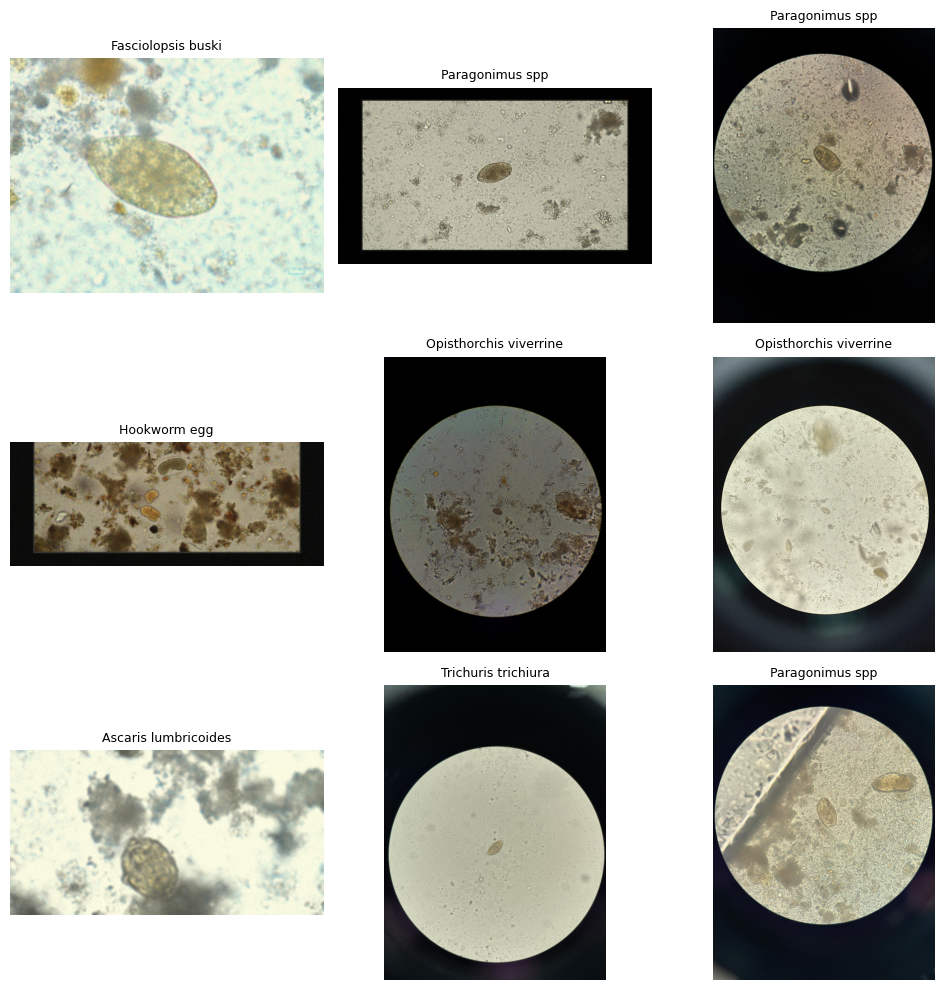

In [ ]:
# ดูตัวอย่างภาพ 9 รูป
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
sample_df = df.sample(min(9, len(df)), random_state=42).reset_index(drop=True)

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    img = keras.utils.load_img(row["filepath"])
    ax.imshow(img)
    ax.set_title(row["label"], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 4) Encode label และ split train/validation
# -----------------------------
le = LabelEncoder()
df["class_id"] = le.fit_transform(df["label"])
class_names = list(le.classes_)
num_classes = len(class_names)

print("Class names:", class_names)
print("Num classes:", num_classes)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["class_id"]
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Class names: ['Ascaris lumbricoides', 'Capillaria philippinensis', 'Enterobius vermicularis', 'Fasciolopsis buski', 'Hookworm egg', 'Hymenolepis diminuta', 'Hymenolepis nana', 'Opisthorchis viverrine', 'Paragonimus spp', 'Taenia spp. egg', 'Trichuris trichiura']
Num classes: 11
Train size: 9350
Val size: 1650


In [ ]:
# -----------------------------
# 5) สร้าง tf.data pipeline
# -----------------------------
IMG_SIZE = 224
BATCH_SIZE = 512
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

def decode_image(path, label=None):
    img = tf.io.read_file(path)
    # รองรับ jpg/png/webp แบบง่าย ๆ
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    img = tf.cast(img, tf.float32)
    return (img, label) if label is not None else img

with tf.device('/CPU:0'):
    # Augmentation ทำในโมเดล
    data_augmentation = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.30),
            layers.RandomZoom(0.20),
            layers.RandomContrast(0.20),
        ],
        name="augmentation"
    )

    train_paths = train_df["filepath"].values
    train_labels = train_df["class_id"].values.astype(np.int32)

    val_paths = val_df["filepath"].values
    val_labels = val_df["class_id"].values.astype(np.int32)

    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    train_ds = train_ds.shuffle(len(train_df), seed=SEED, reshuffle_each_iteration=True)
    train_ds = train_ds.map(lambda p, y: decode_image(p, y), num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    val_ds = val_ds.map(lambda p, y: decode_image(p, y), num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [ ]:
# -----------------------------
# 6) สร้างโมเดล CNN (EfficientNetV2S)
# -----------------------------
tf.keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

# ใช้ EfficientNetV2S แทนเนื่องจากไม่มี EfficientNetV2B4 ใน Keras
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_tensor=x,
    pooling=None
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs, name="parasite_egg_efficientnetv2s")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "parasite_egg_efficientnetv2s"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        384 │ block2a_expand_c

 Total params: 20,668,267 (78.84 MB)

 Trainable params: 333,835 (1.27 MB)

 Non-trainable params: 20,334,432 (77.57 MB)

In [ ]:
# -----------------------------
# 7) เทรนรอบแรก
# -----------------------------
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.1127 - loss: 3.1836
Epoch 1: val_accuracy improved from None to 0.20909, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 968ms/step - accuracy: 0.1276 - loss: 3.0546 - val_accuracy: 0.2091 - val_loss: 2.2365 - learning_rate: 1.0000e-04
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2062 - loss: 2.6554
Epoch 2: val_accuracy improved from 0.20909 to 0.36061, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 610ms/step - accuracy: 0.2204 - loss: 2.5643 - val_accuracy: 0.3606 - val_loss: 2.0534 - learning_rate: 1.0000e-04
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.2657 - loss: 2.3421
Epoch 3: val_accuracy improved from 0.36061 to 0.47152, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s

In [ ]:
# -----------------------------
# 8) Fine-tuning
# -----------------------------
# ปลดล็อกบางส่วนของ backbone เพื่อเพิ่ม performance
base_model.trainable = True

# freeze ชั้นต้น ๆ ไว้ และ fine-tune เฉพาะชั้นท้าย ๆ
fine_tune_at = max(0, len(base_model.layers) - 50)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.6161 - loss: 1.1213
Epoch 1: val_accuracy did not improve from 0.82000
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 724ms/step - accuracy: 0.6172 - loss: 1.1166 - val_accuracy: 0.7873 - val_loss: 0.6587 - learning_rate: 1.0000e-05
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6237 - loss: 1.1110
Epoch 2: val_accuracy did not improve from 0.82000
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 556ms/step - accuracy: 0.6227 - loss: 1.1015 - val_accuracy: 0.7794 - val_loss: 0.6660 - learning_rate: 1.0000e-05
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.6262 - loss: 1.0743
Epoch 3: val_accuracy did not improve from 0.82000

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 558ms/step - accuracy: 0.6306 - loss: 1.0684 - val_accuracy: 0.7855 - val_loss: 0.6454 - learning_rate: 1.0000e-05
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6368 - 

In [ ]:
model.load_weights('best_model.keras')

# ใช้ตัวแปร base_model ที่ประกาศไว้ตอนสร้างโมเดล หรือดึงจากเลเยอร์ที่ 4 (ลำดับที่ 4 มักจะเป็น backbone ใน Functional API นี้)
# เพื่อความชัวร์ เราจะใช้ตัวแปร base_model ที่มีอยู่แล้วใน Kernel
base_model.trainable = True

# ปลดล็อก 100 เลเยอร์สุดท้ายของ backbone
fine_tune_at = max(0, len(base_model.layers) - 100)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Starting deep fine-tuning...')
history_deep_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Starting deep fine-tuning...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 102 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.6245 - loss: 1.0935
Epoch 1: val_accuracy did not improve from 0.82000
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 720ms/step - accuracy: 0.6194 - loss: 1.1171 - val_accuracy: 0.7836 - val_loss: 0.6676 - learning_rate: 5.0000e-06
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6104 - loss: 1.1437
Epoch 2: val_accuracy did not improve from 0.82000
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 539ms/step - accuracy: 0.6163 - loss: 1.1340 - val_accuracy: 0.7776 - val_loss: 0.6784 - learning_rate: 5.0000e-06
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.6348 - loss: 1.0909
Epoch 3: val_accuracy did not improve from 0.82000

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 540ms/step - accuracy: 0.6297 - loss: 1.0988 - val_accuracy: 0.7812 - val_loss: 0.6605 - learning_rate: 5.0000e-06
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6281 - loss: 1.096

In [ ]:
# -----------------------------
# 9) ประเมินผลบน validation
# -----------------------------
val_probs = model.predict(val_ds, verbose=0)
val_pred = val_probs.argmax(axis=1)
val_conf = val_probs.max(axis=1)
val_entropy = -(val_probs * np.log(np.clip(val_probs, 1e-8, 1.0))).sum(axis=1)

val_acc = accuracy_score(val_labels, val_pred)
val_f1 = f1_score(val_labels, val_pred, average="macro")
print(f"Val accuracy: {val_acc:.4f}")
print(f"Val macro-F1: {val_f1:.4f}")

print(classification_report(val_labels, val_pred, target_names=class_names))

# -----------------------------
# 10) ตั้ง threshold สำหรับ Unknown (-1)
# -----------------------------
# ใช้ confidence/entropy ของตัวอย่างที่โมเดลทายถูกใน validation
correct_mask = (val_pred == val_labels)

if correct_mask.any():
    conf_threshold = float(np.quantile(val_conf[correct_mask], 0.10))
    entropy_threshold = float(np.quantile(val_entropy[correct_mask], 0.90))
else:
    conf_threshold = 0.60
    entropy_threshold = 2.0

# ปรับค่าให้อยู่ในช่วงที่สมเหตุสมผล
conf_threshold = max(0.35, min(conf_threshold, 0.95))
entropy_threshold = max(0.5, entropy_threshold)

print("conf_threshold   =", conf_threshold)
print("entropy_threshold=", entropy_threshold)

Val accuracy: 0.7836
Val macro-F1: 0.7810
                           precision    recall  f1-score   support

     Ascaris lumbricoides       0.78      0.65      0.71       150
Capillaria philippinensis       0.86      0.63      0.73       150
  Enterobius vermicularis       0.84      0.76      0.80       150
       Fasciolopsis buski       0.83      0.87      0.85       150
             Hookworm egg       0.87      0.99      0.92       150
     Hymenolepis diminuta       0.75      0.91      0.82       150
         Hymenolepis nana       0.72      0.84      0.78       150
   Opisthorchis viverrine       0.70      0.71      0.71       150
          Paragonimus spp       0.93      0.62      0.74       150
          Taenia spp. egg       0.78      0.79      0.79       150
      Trichuris trichiura       0.67      0.85      0.75       150

                 accuracy                           0.78      1650
                macro avg       0.79      0.78      0.78      1650
             weigh

In [ ]:
# -----------------------------
# 11) เตรียม test set และสร้าง submission
# -----------------------------
def natural_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', str(s))]

def find_test_images(test_dir):
    if test_dir is None:
        return []
    paths = [p for p in Path(test_dir).rglob("*") if p.suffix.lower() in IMG_EXTS]
    return sorted(paths, key=lambda p: natural_key(p.name))

test_paths = find_test_images(test_dir)
print("Test images found:", len(test_paths))

sample_sub = pd.read_csv(sample_submission_path)
print(sample_sub.head())
print("Submission columns:", sample_sub.columns.tolist())

# map filename -> full path
path_map = {p.stem: str(p) for p in test_paths}
path_map_ext = {p.name: str(p) for p in test_paths}

def resolve_test_order(sample_df, test_paths):
    # ตรวจสอบชื่อคอลัมน์ที่ใช้ระบุชื่อไฟล์ (Id หรือ filename)
    id_col = "filename" if "filename" in sample_df.columns else "Id"

    ids = sample_df[id_col].astype(str).tolist()
    resolved = []
    for i, item in enumerate(ids):
        if item in path_map:
            resolved.append(path_map[item])
        elif item in path_map_ext:
            resolved.append(path_map_ext[item])
        else:
            resolved = []
            break
    if resolved:
        return resolved

    # fallback: ตามลำดับไฟล์ที่เรียงไว้
    if len(sample_df) == len(test_paths):
        return [str(p) for p in test_paths]

    # fallback สุดท้าย: ตัดให้เท่ากัน
    n = min(len(sample_df), len(test_paths))
    return [str(p) for p in test_paths[:n]]

resolved_test_paths = resolve_test_order(sample_sub, test_paths)
print("Resolved paths:", len(resolved_test_paths))

Test images found: 2002
     filename  label
0  000000.png   -1.0
1  000001.png   -1.0
2  000002.png   -1.0
3  000003.png    NaN
4  000004.png    NaN
Submission columns: ['filename', 'label']
Resolved paths: 2000


In [ ]:
# ทำ prediction เป็น batch
def predict_dataset(image_paths, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices(image_paths)
    ds = ds.map(lambda p: decode_image(p), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    probs = model.predict(ds, verbose=0)
    return probs

test_probs = predict_dataset(resolved_test_paths, batch_size=BATCH_SIZE)
test_pred = test_probs.argmax(axis=1)
test_conf = test_probs.max(axis=1)
test_entropy = -(test_probs * np.log(np.clip(test_probs, 1e-8, 1.0))).sum(axis=1)

predicted_labels = []
for c, e, idx in zip(test_conf, test_entropy, test_pred):
    if (c < conf_threshold) or (e > entropy_threshold):
        predicted_labels.append(-1)
    else:
        predicted_labels.append(int(idx))

# ตรวจสถิติคร่าว ๆ
predicted_labels = np.array(predicted_labels, dtype=int)
print("Unknown ratio:", (predicted_labels == -1).mean())
print(pd.Series(predicted_labels).value_counts().sort_index().head(20))

Unknown ratio: 0.407
-1     814
 0       2
 1      51
 2     305
 3     136
 4       2
 5      54
 6     294
 7     248
 8      10
 9      20
 10     64
Name: count, dtype: int64


In [ ]:
# -----------------------------
# 12) สร้างไฟล์ submission.csv ตาม template
# -----------------------------
submission = sample_sub.copy()

# ถ้าจำนวนแถวไม่เท่ากันให้ตัดตามขนาดที่ match
n = min(len(submission), len(predicted_labels))
submission = submission.iloc[:n].copy()

# นำ Predicted ใส่แทนในคอลัมน์ label
submission["label"] = predicted_labels[:n]

out_path = "submission.csv"
submission.to_csv(out_path, index=False)

print("Saved:", out_path)
print(submission.head())

Saved: submission.csv
     filename  label
0  000000.png     -1
1  000001.png      6
2  000002.png     -1
3  000003.png     -1
4  000004.png     -1


In [ ]:
# -----------------------------
# 13) บันทึก mapping คลาสไว้ตรวจสอบภายหลัง
# -----------------------------
meta = {
    "class_names": class_names,
    "class_to_id": {name: int(i) for i, name in enumerate(class_names)},
    "conf_threshold": conf_threshold,
    "entropy_threshold": entropy_threshold,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
}
with open("training_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(json.dumps(meta, ensure_ascii=False, indent=2))

{
  "class_names": [
    "Ascaris lumbricoides",
    "Capillaria philippinensis",
    "Enterobius vermicularis",
    "Fasciolopsis buski",
    "Hookworm egg",
    "Hymenolepis diminuta",
    "Hymenolepis nana",
    "Opisthorchis viverrine",
    "Paragonimus spp",
    "Taenia spp. egg",
    "Trichuris trichiura"
  ],
  "class_to_id": {
    "Ascaris lumbricoides": 0,
    "Capillaria philippinensis": 1,
    "Enterobius vermicularis": 2,
    "Fasciolopsis buski": 3,
    "Hookworm egg": 4,
    "Hymenolepis diminuta": 5,
    "Hymenolepis nana": 6,
    "Opisthorchis viverrine": 7,
    "Paragonimus spp": 8,
    "Taenia spp. egg": 9,
    "Trichuris trichiura": 10
  },
  "conf_threshold": 0.5386044383049011,
  "entropy_threshold": 1.2676724195480347,
  "img_size": 224,
  "batch_size": 512
}
